# Argus — CNN Training (Face Crops)

A small CNN trained directly on cropped RGB face images — no hand-engineered features at all.
Like `04_random_forest_training.ipynb` and `05_dense_nn_training.ipynb`, this is a single-image-
in, single-label-out model: one cropped face predicts one drowsiness level, no sequence, no
buffer across frames.

**Reads:** `dataset_processed/face_crops_index.csv` and the `.jpg` files it points to, written by
[`06_dataset_creation_face_crops.ipynb`](./06_dataset_creation_face_crops.ipynb) — run that first.

**Writes:** `models/cnn_face_crops_<VERSION>.keras`.

**Also reads:** `dataset_processed/face_crops.zip` on Drive — a zip of `06`'s `face_crops/` output folder, copied and unzipped onto local Colab disk once per session
(see "Copying Face Crops from Drive" below) instead of letting the `tf.data` pipeline read
thousands of small JPEGs straight off Drive's FUSE mount, the same fix
`11_cnn_lstm_training_drive_pull.ipynb` applied for the same reason. Zip `face_crops/`
yourself and upload it next to `face_crops_index.csv` if it isn't already there — if you've
already run `11_cnn_lstm_training_drive_pull.ipynb`, this is the same zip it expects, so it's
likely already on Drive.

**Why "tiny" (and why a pretrained backbone variant too).** The other three model families
(LSTM, RandomForest, Dense NN) all work from a 59-dimensional-or-smaller hand-engineered feature
vector. This model instead has to learn visual features from raw pixels, which is a fundamentally
harder learning problem to solve from the amount of data this project has (tens of subjects, not
the thousands a large vision model would want) — so the from-scratch architecture below is
deliberately small and heavily regularized (few conv blocks, dropout, no pretrained backbone)
rather than a scaled-up architecture that would likely just overfit. Alongside it, this notebook
also trains and evaluates a frozen-ImageNet-MobileNetV2 variant (`build_mobilenet_backbone`,
optionally fine-tuned) side by side, specifically to test whether pretrained features generalize
across held-out subjects better than what the from-scratch model can learn from this data budget
— see the "MobileNetV2 Transfer-Learning Variant" section below. This is also the only model
family with a plausible path to running its own inference directly on cropped camera frames
without the geometric-feature pipeline at all, which is worth noting for the titulación report as
an architectural alternative, even though the project is standardizing on the LSTM for deployment
(see `03_model_training_lstm.ipynb`'s Design Decision cell) — this notebook exists to have that
comparison on record, not to replace it.


## Setup

Mounts Drive, defines the paths this notebook needs, loads `face_crops_index.csv`, and
initializes model-versioning config. Independent of any other notebook's in-memory state — only
depends on `face_crops_index.csv` and the images it references.


In [1]:
from google.colab import drive
import os
import datetime
import pandas as pd

drive.mount('/content/drive')

# --- Argus project paths (must match 06_dataset_creation_face_crops.ipynb) ---
project_folder = "/content/drive/MyDrive/Argus"
models_folder = f"{project_folder}/models"
dataset_folder = f"{project_folder}/dataset"
processed_folder = f"{dataset_folder}/dataset_processed"
face_crops_index_csv_path = os.path.join(processed_folder, "face_crops_index.csv")

if not os.path.exists(face_crops_index_csv_path):
    raise FileNotFoundError(
        f"'{face_crops_index_csv_path}' not found. Run 06_dataset_creation_face_crops.ipynb "
        "first — this notebook only reads the dataset it produces, it doesn't build it."
    )

df_face_crops = pd.read_csv(face_crops_index_csv_path)
print(f"Loaded face crop index: {len(df_face_crops)} images, "
      f"{df_face_crops['subject'].nunique()} subjects.")

# --- Model Management Configuration ---
FORCE_RETRAIN = True
VERSION_STR = datetime.datetime.now().strftime("%Y%m%d_%H%M")
# Two model paths -- this notebook now trains two binary variants (a from-scratch CNN and a
# MobileNetV2-backed one) side by side for comparison, not just one.
cnn_scratch_model_path = os.path.join(models_folder, f"cnn_face_crops_scratch_{VERSION_STR}.keras")
cnn_mobilenet_model_path = os.path.join(models_folder, f"cnn_face_crops_mobilenet_{VERSION_STR}.keras")

def get_latest_model(folder, prefix, extension):
    """Return the path of the most recently versioned model matching prefix/extension, or None."""
    if not os.path.exists(folder):
        return None
    files = [f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith(extension)]
    if not files:
        return None
    return os.path.join(folder, sorted(files)[-1])

print(f"✅ Model management initialized. Current version: {VERSION_STR}. Force retrain: {FORCE_RETRAIN}")


Mounted at /content/drive
Loaded face crop index: 44778 images, 54 subjects.
✅ Model management initialized. Current version: 20260904_0236. Force retrain: True


## Splitting the Dataset

Group-aware split by subject, same rationale as every other notebook: crops from the same clip
are highly correlated (near-duplicate faces a few frames apart), so a plain random split would
leak near-duplicates across train/test and inflate reported accuracy.

The task is binary (`Not Drowsy` / `Drowsy`). A subject is eligible to be held out as a **test
or validation** subject only if it has crops for **both** classes — a single-class held-out fold
can't score both classes. Subjects missing a class entirely (e.g. a clip that failed extraction)
are **not excluded from the dataset** — they stay in the training pool as valid examples for
whichever class they do have — they're just never picked for the held-out folds. Test and
validation are two disjoint subject groups drawn from a `StratifiedGroupKFold` over the eligible
subjects; every other subject is training.

The split happens on the **index CSV** (file paths + labels), before any image is decoded — the
actual pixel loading happens lazily in the `tf.data` pipeline below.


In [2]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np


def split_by_subject_fold(df, fold_idx=0, n_splits=None, random_state=42):
    """Subject-grouped train/val/test split for face crops, parameterized by fold index so the
    same logic can drive both the main fold-0 split below AND the subject-fold cross-validation
    diagnostic further down this notebook -- without duplicating the split rules in two places.

    Binary task (Not Drowsy / Drowsy). A subject is "complete" if it has crops for BOTH classes
    {1, 2}; only complete subjects can be held out as *test* or *validation* subjects, since a
    single-class held-out fold can't score both classes. Incomplete subjects (only one class
    present -- e.g. a failed clip extraction) are NOT dropped: they stay in the training pool as
    valid examples for whichever class they have.

        test  = fold `fold_idx` of a StratifiedGroupKFold over the complete subjects
        val   = fold `(fold_idx + 1) % n_splits` -- a different, disjoint subject group
        train = every other complete subject + all incomplete subjects

    The 3-class version of this notebook derived `val` from the pool of class-incomplete subjects
    instead. Under binary labels almost every UTA-RLDD subject has both classes (each recorded an
    alert clip and a drowsy clip), so that pool is usually empty -- hence val is now a KFold fold
    like test.

    Returns (df_train, df_val, df_test, complete_subjects, incomplete_subjects, n_splits_used).
    """
    subject_level_sets = df.groupby('subject')['level'].agg(set)
    complete_subjects = subject_level_sets[subject_level_sets == {1, 2}].index
    incomplete_subjects = subject_level_sets.index.difference(complete_subjects)

    if len(complete_subjects) < 3:
        raise ValueError(
            f"Only {len(complete_subjects)} subject(s) have both classes ({list(complete_subjects)}) "
            "-- need at least 3 to hold one out for testing and one for validation. Extract more "
            "subjects (06_dataset_creation_face_crops.ipynb) before training."
        )

    df_complete = df[df['subject'].isin(complete_subjects)]
    n_splits = n_splits or min(5, len(complete_subjects))
    if not (0 <= fold_idx < n_splits):
        raise ValueError(f"fold_idx={fold_idx} out of range for n_splits={n_splits}")

    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_subjects = [
        set(df_complete.iloc[test_pos]['subject'])
        for _, test_pos in sgkf.split(df_complete, df_complete['level'], groups=df_complete['subject'])
    ]

    test_subjects = fold_subjects[fold_idx]
    val_subjects = fold_subjects[(fold_idx + 1) % n_splits]

    test_mask = df['subject'].isin(test_subjects)
    val_mask = df['subject'].isin(val_subjects)
    train_mask = ~test_mask & ~val_mask

    df_train = df[train_mask].reset_index(drop=True)
    df_val = df[val_mask].reset_index(drop=True)
    df_test = df[test_mask].reset_index(drop=True)

    all_levels = set(df['level'].unique())
    for name, part in (('Validation', df_val), ('Test', df_test)):
        missing = all_levels - set(part['level'].unique())
        if missing:
            raise ValueError(f"{name} fold missing level(s) {sorted(missing)} -- treat as a bug.")

    return df_train, df_val, df_test, complete_subjects, incomplete_subjects, n_splits


# Main split used by the rest of the notebook: fold 0 of the StratifiedGroupKFold, same fold the
# notebook has always used. The subject-fold cross-validation section further down reruns
# split_by_subject_fold() across the other folds to check how much this single fold's number
# varies against a different held-out subject draw.
df_train, df_val, df_test, complete_subjects, incomplete_subjects, N_SPLITS = split_by_subject_fold(
    df_face_crops, fold_idx=0
)

print(f"{len(complete_subjects)} subject(s) with both classes, eligible for the test/val folds: "
      f"{sorted(complete_subjects)}")
if len(incomplete_subjects) > 0:
    print(f"{len(incomplete_subjects)} single-class subject(s) folded into training only "
          f"(ineligible for held-out folds): {sorted(incomplete_subjects)}")

print(f"\nTrain: {len(df_train)} crops ({df_train['subject'].nunique()} subjects)")
print(f"Val:   {len(df_val)} crops ({df_val['subject'].nunique()} subjects)")
print(f"Test:  {len(df_test)} crops ({df_test['subject'].nunique()} subjects)")
print("\nPer-class support (1 = Not Drowsy, 2 = Drowsy):")
print("  Train:", df_train['level'].value_counts().sort_index().to_dict())
print("  Val:  ", df_val['level'].value_counts().sort_index().to_dict())
print("  Test: ", df_test['level'].value_counts().sort_index().to_dict())


50 subject(s) with both classes, eligible for the test/val folds: ['subject_03', 'subject_04', 'subject_05', 'subject_06', 'subject_07', 'subject_08', 'subject_09', 'subject_10', 'subject_11', 'subject_12', 'subject_13', 'subject_14', 'subject_15', 'subject_16', 'subject_17', 'subject_18', 'subject_19', 'subject_20', 'subject_21', 'subject_22', 'subject_23', 'subject_24', 'subject_25', 'subject_26', 'subject_27', 'subject_28', 'subject_29', 'subject_30', 'subject_31', 'subject_32', 'subject_33', 'subject_34', 'subject_35', 'subject_36', 'subject_37', 'subject_39', 'subject_40', 'subject_41', 'subject_42', 'subject_43', 'subject_44', 'subject_45', 'subject_46', 'subject_47', 'subject_48', 'subject_49', 'subject_50', 'subject_51', 'subject_53', 'subject_54']
4 single-class subject(s) folded into training only (ineligible for held-out folds): ['subject_01', 'subject_02', 'subject_38', 'subject_52']

Train: 27639 crops (34 subjects)
Val:   8439 crops (10 subjects)
Test:  8700 crops (10 sub

## Copying Face Crops from Drive

This notebook has always let the `tf.data` pipeline below read each crop JPEG straight off
Drive's FUSE mount via `image_path` — thousands of small individual reads. That's exactly the
pattern `10_cnn_lstm_training.ipynb` traced `Input/output error` / `A Google Drive timeout has
occurred` back to; this notebook has just gotten away with it so far because its crop count is
smaller. Rather than wait to hit the same failure, this applies the same fix
`11_cnn_lstm_training_drive_pull.ipynb` already uses: copy `face_crops.zip` off Drive once
(one big sequential transfer, none of the per-file overhead of many small concurrent reads),
unzip it to local Colab disk, then rewrite `image_path` (matched by filename, not by
prefix-replacing the original Drive path) to point at the local copy.


In [3]:
import os
import shutil
import zipfile

ZIP_NAME = "face_crops.zip"
LOCAL_FACE_CROPS_DIR = "/content/face_crops_local"
os.makedirs(LOCAL_FACE_CROPS_DIR, exist_ok=True)

_drive_zip = os.path.join(processed_folder, ZIP_NAME)
_local_zip = f"/content/{ZIP_NAME}"

# Validation: Check if local zip exists and is actually a zip file
if os.path.exists(_local_zip):
    try:
        with zipfile.ZipFile(_local_zip, 'r') as zf:
            if zf.testzip() is not None:
                raise zipfile.BadZipFile("Zip file corrupted")
    except zipfile.BadZipFile:
        print(f"⚠️  {_local_zip} is invalid/corrupted. Removing to force re-copy.")
        os.remove(_local_zip)

if not os.path.exists(_local_zip):
    if not os.path.exists(_drive_zip):
        raise FileNotFoundError(
            f"'{_drive_zip}' not found on Drive. Zip the face_crops/ folder "
            "(06_dataset_creation_face_crops.ipynb's output) outside Colab, upload it into "
            "processed_folder, or fix ZIP_NAME above."
        )
    print(f"Copying {_drive_zip} -> {_local_zip} (one sequential transfer off Drive) ...")
    shutil.copy(_drive_zip, _local_zip)
else:
    print(f"{_local_zip} already on local disk and validated -- using it.")

print(f"Unzipping {_local_zip} -> {LOCAL_FACE_CROPS_DIR} ...")
with zipfile.ZipFile(_local_zip, 'r') as zf:
    zf.extractall(LOCAL_FACE_CROPS_DIR)

# Flatten structure if necessary
for _root, _dirs, _filenames in os.walk(LOCAL_FACE_CROPS_DIR):
    for _fn in _filenames:
        _src = os.path.join(_root, _fn)
        _dst = os.path.join(LOCAL_FACE_CROPS_DIR, _fn)
        if _src != _dst:
            os.replace(_src, _dst)

_n_local = len([f for f in os.listdir(LOCAL_FACE_CROPS_DIR)
                if os.path.isfile(os.path.join(LOCAL_FACE_CROPS_DIR, f))])
print(f"Done: {_n_local} files at {LOCAL_FACE_CROPS_DIR}.")

def _localize_image_path(path: str) -> str:
    return os.path.join(LOCAL_FACE_CROPS_DIR, os.path.basename(path))

for _df in (df_face_crops, df_train, df_val, df_test):
    _df["image_path"] = _df["image_path"].apply(_localize_image_path)

_sample_path = df_train["image_path"].iloc[0]
assert os.path.exists(_sample_path), f"{_sample_path} not found locally."
print(f"Paths localized to {LOCAL_FACE_CROPS_DIR}.")

Copying /content/drive/MyDrive/Argus/dataset/dataset_processed/face_crops.zip -> /content/face_crops.zip (one sequential transfer off Drive) ...
Unzipping /content/face_crops.zip -> /content/face_crops_local ...
Done: 44778 files at /content/face_crops_local.
Paths localized to /content/face_crops_local.


## Building the `tf.data` Pipeline

Crops are variable-size (see `06_dataset_creation_face_crops.ipynb`), so every image is resized
to a fixed `IMG_SIZE x IMG_SIZE` here. `IMG_SIZE = 96` is chosen as a small-but-workable input
resolution for a *tiny* CNN — large enough to keep eye/mouth detail legible after the face
detector's crop, small enough to keep the model and its memory footprint modest. Pixel scaling
(`1/255`) is done as a `Rescaling` layer inside the model itself (see the model definition below)
rather than as a separate `StandardScaler` artifact, so the trained `.keras` file is a fully
self-contained image-in, prediction-out artifact with no companion scaler file to keep in sync.


In [4]:
import tensorflow as tf

IMG_SIZE = 96
BATCH_SIZE = 32
CLASS_NAMES = ['Not Drowsy', 'Drowsy']

# --- Minority-class balancing strategy ---
# The crop set is ~2:1 Not Drowsy : Drowsy. Two ways to correct that: reweight the loss
# (class_weight, what this notebook did before) or resample so every batch is ~50/50
# (USE_BALANCED_SAMPLING). Resampling gives the optimizer a stable per-batch class mix instead
# of a reweighted-gradient correction, and pairs cleanly with the decision-threshold cell after
# evaluation (which sets the final Drowsy operating point). When this is True the training set
# is drawn 50/50 from the two classes with tf.data.Dataset.sample_from_datasets, class_weight
# is set to None in the training cell, and an explicit steps_per_epoch is passed.
USE_BALANCED_SAMPLING = True

def load_and_preprocess(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

# Augmentation beyond plain flip+brightness: the first training run reached >99% train accuracy
# within 2 epochs on a 28K-param model trained over only 4 subjects -- a strong sign it was keying
# on subject identity (skin tone, lighting, background) rather than drowsiness cues, which a
# held-out subject's face doesn't share. Small rotation/zoom/contrast jitter make that identity
# shortcut harder to exploit while staying mild enough not to distort the drowsiness-relevant
# eye/mouth region the way aggressive geometric augmentation would.
geometric_augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),   # ~+/-18 degrees
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
])

def make_dataset(df, training: bool, balanced: bool = False):
    paths = df['image_path'].to_numpy()
    labels = (df['level'].to_numpy(dtype=np.int32) - 1)  # 0-indexed: 0=Not Drowsy, 1=Drowsy

    if training and balanced:
        # One infinite, per-class-shuffled stream per class, interleaved 50/50. Every batch then
        # has a stable ~even class mix regardless of the underlying 2:1 imbalance.
        per_class = []
        for cls in (0, 1):
            m = labels == cls
            per_class.append(
                tf.data.Dataset.from_tensor_slices((paths[m], labels[m]))
                .shuffle(int(m.sum()), seed=42, reshuffle_each_iteration=True)
                .repeat()
            )
        ds = tf.data.Dataset.sample_from_datasets(per_class, weights=[0.5, 0.5], seed=42)
    else:
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        if not balanced:
            ds = ds.shuffle(buffer_size=2048, seed=42)  # balanced path already shuffles per class
        ds = ds.map(lambda img, lbl: (tf.image.random_flip_left_right(img), lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda img, lbl: (tf.image.random_brightness(img, max_delta=0.15), lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda img, lbl: (geometric_augmenter(img, training=True), lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# One "epoch" keeps roughly the same number of gradient steps as the unbalanced pipeline, so the
# balanced (infinite) training set needs an explicit length -- passed to .fit(steps_per_epoch=)
# in the training cell.
STEPS_PER_EPOCH_TRAIN = int(np.ceil(len(df_train) / BATCH_SIZE))

train_ds = make_dataset(df_train, training=True, balanced=USE_BALANCED_SAMPLING)
val_ds = make_dataset(df_val, training=False)
test_ds = make_dataset(df_test, training=False)

print(f"IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, "
      f"balanced_sampling={USE_BALANCED_SAMPLING}, steps_per_epoch={STEPS_PER_EPOCH_TRAIN}")


IMG_SIZE=96, BATCH_SIZE=32, balanced_sampling=True, steps_per_epoch=864


## Tiny CNN Model Definition

Three convolutional blocks (`Conv2D -> BatchNorm -> MaxPool`), increasing filter count, followed
by `GlobalAveragePooling2D` (instead of `Flatten` + a large `Dense` layer, to keep parameter
count down and reduce overfitting risk) and a small classification head.


In [5]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Rescaling, Conv2D, BatchNormalization, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout,
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import SparseCategoricalCrossentropy, CategoricalCrossentropy
import tensorflow as tf
import keras

num_classes = len(CLASS_NAMES)

USE_FOCAL_LOSS = True
FOCAL_GAMMA = 2.0
LABEL_SMOOTHING = 0.05

@keras.saving.register_keras_serializable(package="CustomLosses")
class SparseCategoricalFocalLoss(keras.losses.Loss):
    # FIX: Default reduction to 'sum_over_batch_size' instead of Reduction.AUTO to support Keras 3
    def __init__(self, gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING, reduction='sum_over_batch_size', name='sparse_categorical_focal_loss'):
        super().__init__(reduction=reduction, name=name)
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.cce_per_example = CategoricalCrossentropy(from_logits=False, reduction=None)

    def call(self, y_true, y_pred):
        y_true_int = tf.cast(y_true, tf.int32)
        num_classes_tensor = tf.shape(y_pred)[1]
        y_true_one_hot = tf.one_hot(y_true_int, depth=num_classes_tensor)

        if self.label_smoothing > 0.0:
            num_classes_float = tf.cast(num_classes_tensor, tf.float32)
            y_true_one_hot = y_true_one_hot * (1.0 - self.label_smoothing) + (self.label_smoothing / num_classes_float)

        ce = self.cce_per_example(y_true_one_hot, y_pred)
        probs_true_class = tf.reduce_sum(y_pred * y_true_one_hot, axis=-1)
        probs_true_class = tf.clip_by_value(probs_true_class, 1e-7, 1.0 - 1e-7)

        modulating_factor = tf.pow(1.0 - probs_true_class, self.gamma)
        return modulating_factor * ce

    def get_config(self):
        config = super().get_config()
        config.update({
            'gamma': self.gamma,
            'label_smoothing': self.label_smoothing,
        })
        return config

def build_loss():
    if USE_FOCAL_LOSS:
        return SparseCategoricalFocalLoss(gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING)
    return SparseCategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

def build_cnn_scratch(num_classes=num_classes):
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Rescaling(1. / 255),
        Conv2D(16, 3, padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling2D(),
        Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling2D(),
        Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling2D(),
        GlobalAveragePooling2D(),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax'),
    ], name='cnn_scratch')
    # LR 1e-4 (was 1e-5). 1e-5 is very low for a 28k-param from-scratch CNN -- it forced
    # 100-epoch runs and still overfit. 1e-4 + ReduceLROnPlateau + macro-F1 checkpointing gets
    # to the same place faster; EarlyStopping(restore_best_weights) guards the overfitting tail.
    model.compile(optimizer=Adam(learning_rate=1e-4), loss=build_loss(), metrics=['accuracy'])
    return model

def build_mobilenet_backbone(alpha=0.35, trainable_backbone=False, learning_rate=1e-5):
    base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), alpha=alpha, include_top=False, weights='imagenet')
    base.trainable = trainable_backbone
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = preprocess_input(inputs)
    x = base(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs, name='mobilenet_v2_backbone')
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss=build_loss(), metrics=['accuracy'])
    return model, base

## CNN Model Training

`class_weight`, computed from the training set's actual label distribution, for the same reason
as every other model here: `Drowsy` is plausibly the rarest class and the most safety-critical
one to not neglect. Combined with the `USE_FOCAL_LOSS` toggle and the strengthened `l2`/dropout
regularization from the cell above — see that cell's docstrings for why each was added.


In [6]:
model_scratch = build_cnn_scratch()
model_scratch.summary()


Model: "cnn_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,322 (110.63 KB)

 Trainable params: 28,098 (109.76 KB)

 Non-trainable params: 224 (896.00 B)

In [7]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

class MacroF1Callback(Callback):
    """Adds `val_macro_f1` to the epoch's `logs` dict so EarlyStopping/ModelCheckpoint below can
    select on it instead of raw accuracy. Raw val_accuracy is not a safe selection metric under
    class imbalance -- it's exactly what let a model that always predicted the majority class
    look like an 84.75%-accurate model in the first run of this notebook, while missing every
    single Drowsy case (0.00 recall). Runs one extra prediction pass over the validation set per
    epoch; negligible cost at this model/dataset size.

    Passes explicit labels=[0..num_classes-1] so "macro-F1" always averages the same fixed set
    of classes: without them, sklearn infers labels from whatever's present in a given epoch's
    val predictions, which can silently change what the metric means from epoch to epoch (e.g.
    an epoch where the model never predicts one class).
    """
    def __init__(self, val_ds):
        super().__init__()
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        y_true = np.concatenate([y.numpy() for _, y in self.val_ds])
        proba = self.model.predict(self.val_ds, verbose=0)
        y_pred = np.argmax(proba, axis=1)
        logs['val_macro_f1'] = f1_score(y_true, y_pred, average='macro',
                                         labels=list(range(num_classes)), zero_division=0)
        # Also log macro-F1 at the best per-epoch threshold on p(Drowsy). This is the metric
        # that matches how the model is actually deployed (see the operating-point cell after
        # evaluation). To select the checkpoint at that operating point instead of at argmax,
        # change monitor='val_macro_f1' -> 'val_thr_macro_f1' in the callbacks below.
        if num_classes == 2:
            p_d = proba[:, 1]
            best = max(
                f1_score(y_true, (p_d >= t).astype(int), labels=[0, 1], average='macro',
                         zero_division=0)
                for t in np.arange(0.05, 0.951, 0.05)
            )
            logs['val_thr_macro_f1'] = best

# Class weights computed ONCE here, reused unchanged for the MobileNetV2 variant below -- the
# only thing that differs between the two training runs is architecture, not class balancing.
train_labels = (df_train['level'].to_numpy(dtype=np.int32) - 1)
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
weight_dict = dict(zip(np.unique(train_labels).tolist(), weights))

# Drowsy is the safety-critical class and the one it's least acceptable to regress on -- it had
# the worst recall (0.13-0.27) in the RandomForest / early-CNN runs that first motivated this
# boost. Kept for the binary task: Drowsy (old level 3) is still the minority class and the
# dangerous state to miss. No binary run has happened yet -- once there are real numbers, watch
# whether the boost still helps or starts over-suppressing Not Drowsy precision.
DROWSY_LABEL = CLASS_NAMES.index('Drowsy')  # 1
NOT_DROWSY_LABEL = CLASS_NAMES.index('Not Drowsy')  # 0
# Only used when USE_BALANCED_SAMPLING is False. An earlier run set these to 0.9 / 1.375 -- i.e.
# it tilted the loss AWAY from Drowsy recall, the opposite of the goal. Drowsy gets a boost, Not
# Drowsy is left at its balanced weight; prefer the balanced-sampling path + the threshold cell
# over pushing these further.
DROWSY_WEIGHT_BOOST = 1.5
NOT_DROWSY_WEIGHT_BOOST = 1.0
weight_dict[DROWSY_LABEL] *= DROWSY_WEIGHT_BOOST
weight_dict[NOT_DROWSY_LABEL] *= NOT_DROWSY_WEIGHT_BOOST
print(f"Class weights (Drowsy boosted {DROWSY_WEIGHT_BOOST}x, Not Drowsy {NOT_DROWSY_WEIGHT_BOOST}x): {weight_dict}")
if USE_BALANCED_SAMPLING:
    print("USE_BALANCED_SAMPLING=True -> training with class_weight=None (the 50/50 sampler "
          "already balances every batch); the weights above are ignored this run.")

# EarlyStopping and ModelCheckpoint both monitor val_macro_f1 -- they used to watch val_loss and
# val_accuracy respectively, two different "best" epochs that could (and did) diverge.
# macro_f1_cb must run first in this list so it populates logs['val_macro_f1'] before the other
# two callbacks read it within the same epoch.
#
# All three callbacks watch val_ds (the held-out validation-subject fold from the split cell), NOT
# test_ds. Previously validation_data=test_ds meant every training-time decision -- early
# stopping, which epoch gets checkpointed, the LR-plateau schedule -- was made by watching the
# exact same held-out subject that the eval cell reports the final test number on. There was no
# independent check at all. test_ds is now only ever touched in the evaluation cell below, after
# training is completely finished.
macro_f1_cb_scratch = MacroF1Callback(val_ds)
early_stopping_scratch = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15, restore_best_weights=True)
checkpoint_scratch = ModelCheckpoint(filepath=os.path.join(models_folder, 'best_cnn_scratch_face_crops.keras'),
                                      monitor='val_macro_f1', mode='max', save_best_only=True)
reduce_lr_scratch = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)

print("🚀 Training scratch CNN...")
history_scratch = model_scratch.fit(
    train_ds,
    epochs=100,
    steps_per_epoch=STEPS_PER_EPOCH_TRAIN if USE_BALANCED_SAMPLING else None,
    validation_data=val_ds,
    callbacks=[macro_f1_cb_scratch, early_stopping_scratch, checkpoint_scratch, reduce_lr_scratch],
    class_weight=None if USE_BALANCED_SAMPLING else weight_dict,
    verbose=1,
)

model_scratch.save(cnn_scratch_model_path)
print(f"💾 Model saved: {cnn_scratch_model_path}")


Class weights (Drowsy boosted 1.5x, Not Drowsy 1.0x): {0: np.float64(0.7491868155697712), 1: np.float64(2.254895028826281)}
USE_BALANCED_SAMPLING=True -> training with class_weight=None (the 50/50 sampler already balances every batch); the weights above are ignored this run.
🚀 Training scratch CNN...
Epoch 1/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 164s 179ms/step - accuracy: 0.7177 - loss: 0.2692 - val_accuracy: 0.6273 - val_loss: 0.4064 - val_macro_f1: 0.4805 - val_thr_macro_f1: 0.5303 - learning_rate: 1.0000e-04
Epoch 2/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 141s 163ms/step - accuracy: 0.8559 - loss: 0.2040 - val_accuracy: 0.6546 - val_loss: 0.5381 - val_macro_f1: 0.5180 - val_thr_macro_f1: 0.6078 - learning_rate: 1.0000e-04
Epoch 3/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 149s 173ms/step - accuracy: 0.9069 - loss: 0.1716 - val_accuracy: 0.6567 - val_loss: 0.7095 - val_macro_f1: 0.5333 - val_thr_macro_f1: 0.6000 - learning_rate: 1.0000e-04
Epoch 4/100
864/864 ━━━━━━━━━━━━━━━━━━━━ 158s 183ms/step - accura

## CNN Model Evaluation


Loading best scratch model from /content/drive/MyDrive/Argus/models/best_cnn_scratch_face_crops.keras...

CNN Test Loss: 0.9639
CNN Test Accuracy: 0.5964
272/272 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step
CNN Test Macro-F1: 0.5273

Classification Report (CNN - Best Checkpoint):
              precision    recall  f1-score   support

  Not Drowsy       0.68      0.73      0.71      5800
      Drowsy       0.38      0.32      0.35      2900

    accuracy                           0.60      8700
   macro avg       0.53      0.53      0.53      8700
weighted avg       0.58      0.60      0.59      8700



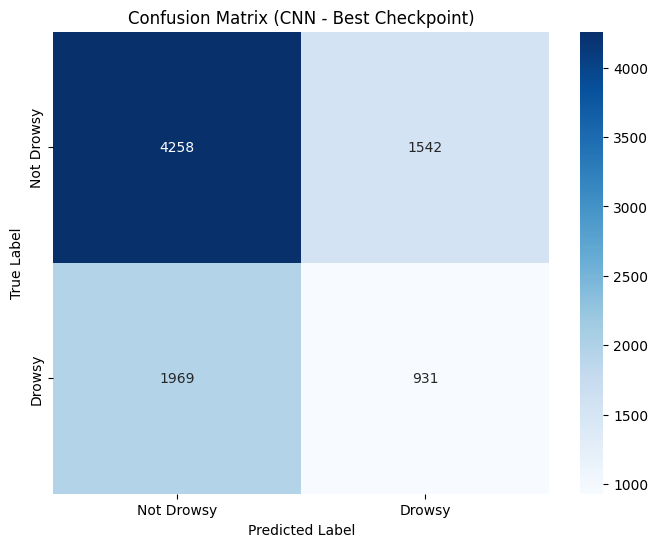

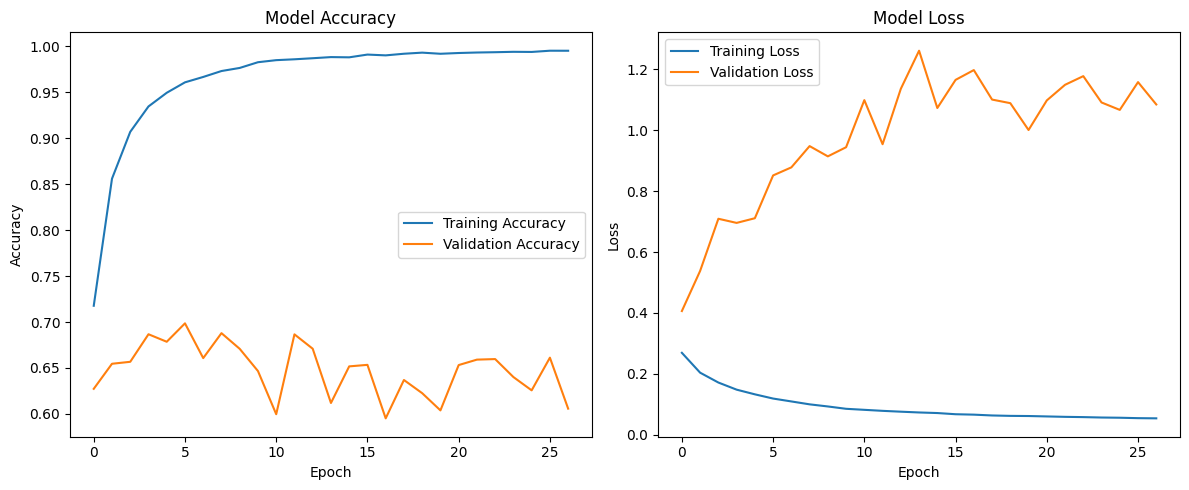

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import keras
import numpy as np

# Load the best saved checkpoint for evaluation
best_scratch_path = os.path.join(models_folder, 'best_cnn_scratch_face_crops.keras')
if os.path.exists(best_scratch_path):
    print(f"Loading best scratch model from {best_scratch_path}...")
    # WORKAROUND: The saved file might still refer to the old 'loss_fn' closure.
    # We map 'loss_fn' to our new serializable class so Keras can resolve it.
    custom_objects = {
        'SparseCategoricalFocalLoss': SparseCategoricalFocalLoss,
        'loss_fn': SparseCategoricalFocalLoss
    }
    model_eval = tf.keras.models.load_model(best_scratch_path, custom_objects=custom_objects)
else:
    print("Best checkpoint not found, falling back to in-memory model.")
    model_eval = model_scratch

loss, accuracy = model_eval.evaluate(test_ds, verbose=0)
print(f"\nCNN Test Loss: {loss:.4f}")
print(f"CNN Test Accuracy: {accuracy:.4f}")
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred_probs = model_eval.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Macro-F1 (unweighted mean of per-class F1) alongside accuracy
print(f"CNN Test Macro-F1: {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

print("\nClassification Report (CNN - Best Checkpoint):")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (CNN - Best Checkpoint)')
plt.show()

# Note: Plotting history still uses the last run's training session object
if 'history_scratch' in globals():
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_scratch.history['accuracy'], label='Training Accuracy')
    plt.plot(history_scratch.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_scratch.history['loss'], label='Training Loss')
    plt.plot(history_scratch.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Operating-Point Selection (decision threshold on p(Drowsy))

The evaluation above reports metrics at the implicit **argmax** threshold (0.5 on the 2-class
softmax). That is almost never the right operating point for a safety-critical minority class.
This cell sweeps the threshold on `p(Drowsy)` on the **validation set**, picks a *safety-first*
operating point (among thresholds whose val `Drowsy` recall ≥ `DROWSY_RECALL_FLOOR`, take the
best `Drowsy` precision), then reports **test** metrics at that threshold next to the argmax
baseline. An isotonic calibrator fitted on val is used to check whether the operating point
transfers to test. The chosen raw-probability threshold is written to
`best_cnn_scratch_face_crops.keras.threshold.json` for `src/cv-argus`.


chosen t* (val) = 0.05  [NO threshold cleared recall 0.70 -- max-recall fallback]
  val @ t*: macro-F1 0.4222  Drowsy P 0.318  R 0.647
max-macro-F1 t (val) = 0.45  (macro-F1 0.6051, Drowsy P 0.522 R 0.372)

--- TEST @ argmax baseline (threshold 0.50) ---
accuracy 0.5964 | macro-F1 0.5273
              precision    recall  f1-score   support

  Not Drowsy       0.68      0.73      0.71      5800
      Drowsy       0.38      0.32      0.35      2900

    accuracy                           0.60      8700
   macro avg       0.53      0.53      0.53      8700
weighted avg       0.58      0.60      0.59      8700

confusion (rows=true, cols=pred):
 [[4258 1542]
 [1969  931]]

--- TEST @ chosen t* (threshold 0.05) ---
accuracy 0.4754 | macro-F1 0.4749
              precision    recall  f1-score   support

  Not Drowsy       0.70      0.38      0.49      5800
      Drowsy       0.35      0.67      0.46      2900

    accuracy                           0.48      8700
   macro avg       0.52    

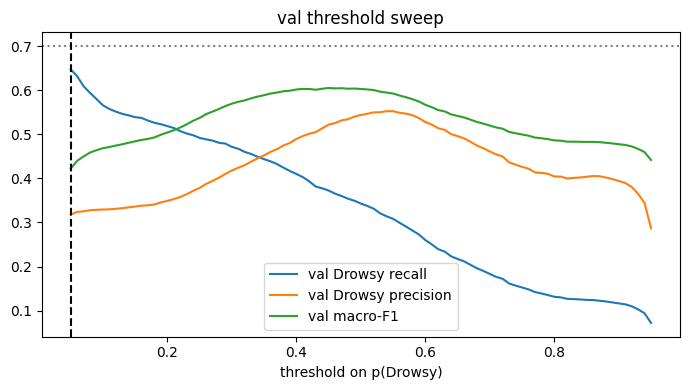


wrote /content/drive/MyDrive/Argus/models/best_cnn_scratch_face_crops.keras.threshold.json


In [9]:
import json
import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.isotonic import IsotonicRegression

DROWSY_RECALL_FLOOR = 0.70          # minimum VALIDATION Drowsy recall to accept -- tune me
GRID = np.round(np.arange(0.05, 0.951, 0.01), 4)

# reuse model_eval / test_ds from the evaluation cell above; get val probabilities too
y_val = np.concatenate([y.numpy() for _, y in val_ds])
p_val = model_eval.predict(val_ds, verbose=0)[:, 1]
y_test = np.concatenate([y.numpy() for _, y in test_ds])
p_test = model_eval.predict(test_ds, verbose=0)[:, 1]


def sweep(y, p):
    out = []
    for t in GRID:
        yh = (p >= t).astype(int)
        out.append(dict(t=float(t),
                        macro_f1=f1_score(y, yh, labels=[0, 1], average='macro', zero_division=0),
                        drowsy_p=precision_score(y, yh, pos_label=1, zero_division=0),
                        drowsy_r=recall_score(y, yh, pos_label=1, zero_division=0)))
    return out


def pick(rows, floor):
    clear = [r for r in rows if r['drowsy_r'] >= floor]
    if clear:
        return max(clear, key=lambda r: (r['drowsy_p'], r['t'])), \
               f"highest t with val Drowsy recall >= {floor:.2f}"
    return max(rows, key=lambda r: r['drowsy_r']), \
           f"NO threshold cleared recall {floor:.2f} -- max-recall fallback"


def report_at(y, p, t, header):
    yh = (p >= t).astype(int)
    print(f"\n--- {header} (threshold {t:.2f}) ---")
    print(f"accuracy {np.mean(y == yh):.4f} | macro-F1 "
          f"{f1_score(y, yh, labels=[0,1], average='macro', zero_division=0):.4f}")
    print(classification_report(y, yh, target_names=CLASS_NAMES, zero_division=0))
    print("confusion (rows=true, cols=pred):\n", confusion_matrix(y, yh, labels=[0, 1]))
    return dict(threshold=float(t), accuracy=float(np.mean(y == yh)),
               macro_f1=float(f1_score(y, yh, labels=[0, 1], average='macro', zero_division=0)),
               drowsy_p=float(precision_score(y, yh, pos_label=1, zero_division=0)),
               drowsy_r=float(recall_score(y, yh, pos_label=1, zero_division=0)))


rows = sweep(y_val, p_val)
star, note = pick(rows, DROWSY_RECALL_FLOOR)
f1_star = max(rows, key=lambda r: r['macro_f1'])
print(f"chosen t* (val) = {star['t']:.2f}  [{note}]")
print(f"  val @ t*: macro-F1 {star['macro_f1']:.4f}  Drowsy P {star['drowsy_p']:.3f}  R {star['drowsy_r']:.3f}")
print(f"max-macro-F1 t (val) = {f1_star['t']:.2f}  (macro-F1 {f1_star['macro_f1']:.4f}, "
      f"Drowsy P {f1_star['drowsy_p']:.3f} R {f1_star['drowsy_r']:.3f})")

base = report_at(y_test, p_test, 0.50, "TEST @ argmax baseline")
tuned = report_at(y_test, p_test, star['t'], "TEST @ chosen t*")

iso = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0).fit(p_val, y_val)
star_c, _ = pick(sweep(y_val, iso.predict(p_val)), DROWSY_RECALL_FLOOR)
report_at(y_test, iso.predict(p_test), star_c['t'], f"TEST @ calibrated t* ({star_c['t']:.2f})")

import matplotlib.pyplot as plt
ts = [r['t'] for r in rows]
plt.figure(figsize=(7, 4))
plt.plot(ts, [r['drowsy_r'] for r in rows], label='val Drowsy recall')
plt.plot(ts, [r['drowsy_p'] for r in rows], label='val Drowsy precision')
plt.plot(ts, [r['macro_f1'] for r in rows], label='val macro-F1')
plt.axhline(DROWSY_RECALL_FLOOR, ls=':', c='grey'); plt.axvline(star['t'], ls='--', c='k')
plt.xlabel('threshold on p(Drowsy)'); plt.legend(); plt.title('val threshold sweep'); plt.tight_layout(); plt.show()

out_path = best_scratch_path + '.threshold.json'
with open(out_path, 'w') as fh:
    json.dump(dict(drowsy_index=1, drowsy_recall_floor=DROWSY_RECALL_FLOOR, threshold=star['t'],
                   selection=note, test_at_threshold=tuned, test_at_argmax=base), fh, indent=2)
print(f"\nwrote {out_path}")


## MobileNetV2 Transfer-Learning Variant (Frozen Backbone → Fine-Tune)

`build_mobilenet_backbone()` was defined above but never actually trained — this section closes
that gap. Two phases, the standard transfer-learning recipe: train the new head to convergence
with the pretrained backbone completely frozen first, *then* unfreeze a small number of the
backbone's final layers and continue training at a much lower learning rate. Fine-tuning the
whole backbone from the start would destroy the pretrained ImageNet features before the new head
has learned anything useful to backpropagate through them.

Uses the exact same `train_ds`/`val_ds`/`test_ds`, `weight_dict`, and val-macro-F1-based
callback pattern as the scratch model above, so any accuracy/recall difference between the two
is attributable to architecture, not to a different training setup.


In [ ]:
model_mobilenet, mobilenet_base = build_mobilenet_backbone(alpha=0.35, trainable_backbone=False)
model_mobilenet.summary()

# Same class_weight dict as the scratch model -- see the cell above for why it's computed once
# and reused. A fresh MacroF1Callback/EarlyStopping/ModelCheckpoint/ReduceLROnPlateau set is
# still needed (Keras callbacks are stateful per-model), but the *pattern* is identical.
macro_f1_cb_mobilenet = MacroF1Callback(val_ds)
early_stopping_mobilenet = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15, restore_best_weights=True)
checkpoint_mobilenet_frozen = ModelCheckpoint(
    filepath=os.path.join(models_folder, 'best_cnn_mobilenet_frozen_face_crops.keras'),
    monitor='val_macro_f1', mode='max', save_best_only=True,
)
reduce_lr_mobilenet = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)

print("🚀 Training MobileNetV2 head (backbone frozen)...")
history_mobilenet_frozen = model_mobilenet.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=[macro_f1_cb_mobilenet, early_stopping_mobilenet, checkpoint_mobilenet_frozen, reduce_lr_mobilenet],
    class_weight=weight_dict,
    verbose=1,
)


2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenet_v2_backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_96             │ (None, 3, 3, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 492,322 (1.88 MB)

 Trainable params: 82,114 (320.76 KB)

 Non-trainable params: 410,208 (1.56 MB)

🚀 Training MobileNetV2 head (backbone frozen)...
Epoch 1/100
  77131/Unknown 9538s 123ms/step - accuracy: 0.8537 - loss: 0.1997

### Fine-tuning phase

Unfreeze the last ~30 layers of the MobileNetV2 base (out of ~150 total at `alpha=0.35`) and
continue training at a much lower learning rate (`1e-5`, vs. the head phase's `1e-3`). Only the
*later* layers are unfrozen — those encode higher-level, more task-specific features; the early
layers (edges, colors, basic textures) are exactly the generic features transfer learning is
meant to keep. `base(x, training=False)` inside the model still keeps BatchNorm's running
statistics frozen throughout — unfreezing a `BatchNormalization` layer's *weights* while it keeps
computing batch statistics from this project's small batches would destabilize training,
independent of which layers are otherwise trainable.


In [ ]:
# Load the best frozen-head checkpoint before fine-tuning
best_frozen_path = os.path.join(models_folder, 'best_cnn_mobilenet_frozen_face_crops.keras')

# Fix: Include custom_objects (and the loss_fn workaround) to enable loading
def focal_loss_loader(**kwargs):
    # Force a valid reduction value if 'auto' or nothing is passed
    kwargs['reduction'] = 'sum_over_batch_size'
    return SparseCategoricalFocalLoss(**kwargs)

custom_objects = {
    'SparseCategoricalFocalLoss': focal_loss_loader,
    'loss_fn': focal_loss_loader
}

print(f"Attempting to load model from {best_frozen_path}...")
model_mobilenet_ft = tf.keras.models.load_model(best_frozen_path, custom_objects=custom_objects)

base_ft = next(l for l in model_mobilenet_ft.layers if isinstance(l, tf.keras.Model))
base_ft.trainable = True
FINE_TUNE_UNFREEZE_LAYERS = 30
for layer in base_ft.layers[:-FINE_TUNE_UNFREEZE_LAYERS]:
    layer.trainable = False
for layer in base_ft.layers[-FINE_TUNE_UNFREEZE_LAYERS:]:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

# FIX: Pass a valid reduction directly to resolve the ValueError from the class default
if USE_FOCAL_LOSS:
    ft_loss = SparseCategoricalFocalLoss(gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING, reduction='sum_over_batch_size')
else:
    ft_loss = SparseCategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING, reduction='sum_over_batch_size')

FINE_TUNE_LR = 1e-5
model_mobilenet_ft.compile(optimizer=Adam(learning_rate=FINE_TUNE_LR),
                            loss=ft_loss, metrics=['accuracy'])

macro_f1_cb_ft = MacroF1Callback(val_ds)
early_stopping_ft = EarlyStopping(monitor='val_macro_f1', mode='max', patience=8, restore_best_weights=True)
checkpoint_ft = ModelCheckpoint(
    filepath=os.path.join(models_folder, 'best_cnn_mobilenet_finetuned_face_crops.keras'),
    monitor='val_macro_f1', mode='max', save_best_only=True,
)
reduce_lr_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-8, verbose=1)

print(f"🚀 Fine-tuning MobileNetV2 (last {FINE_TUNE_UNFREEZE_LAYERS} backbone layers, lr={FINE_TUNE_LR})...")
history_mobilenet_ft = model_mobilenet_ft.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[macro_f1_cb_ft, early_stopping_ft, checkpoint_ft, reduce_lr_ft],
    class_weight=weight_dict,
    verbose=1,
)

model_mobilenet_ft.save(cnn_mobilenet_model_path)
print(f"💾 Model saved: {cnn_mobilenet_model_path}")

### MobileNetV2 Evaluation + Scratch/Frozen/Fine-Tuned Comparison

Same evaluation shape as the scratch model's evaluation cell above, run against the fine-tuned
checkpoint. The comparison table after it is the "side by side" comparison this notebook's setup
cell has claimed to do since before either variant was actually trained.


In [ ]:
best_ft_path = os.path.join(models_folder, 'best_cnn_mobilenet_finetuned_face_crops.keras')
if os.path.exists(best_ft_path):
    print(f"Loading best fine-tuned MobileNetV2 model from {best_ft_path}...")
    model_mobilenet_eval = tf.keras.models.load_model(best_ft_path)
else:
    print("Best fine-tuned checkpoint not found, falling back to in-memory model.")
    model_mobilenet_eval = model_mobilenet_ft

loss_mobilenet, accuracy_mobilenet = model_mobilenet_eval.evaluate(test_ds, verbose=0)
print(f"\nMobileNetV2 (fine-tuned) Test Loss: {loss_mobilenet:.4f}")
print(f"MobileNetV2 (fine-tuned) Test Accuracy: {accuracy_mobilenet:.4f}")

y_pred_probs_mobilenet = model_mobilenet_eval.predict(test_ds)
y_pred_mobilenet = np.argmax(y_pred_probs_mobilenet, axis=1)
# y_true is the same test set/order as the scratch model's evaluation cell above (test_ds is
# never shuffled), so it's reused rather than recomputed.
macro_f1_mobilenet = f1_score(y_true, y_pred_mobilenet, average='macro', zero_division=0)
print(f"MobileNetV2 (fine-tuned) Test Macro-F1: {macro_f1_mobilenet:.4f}")

print("\nClassification Report (MobileNetV2 - Fine-Tuned):")
print(classification_report(y_true, y_pred_mobilenet, target_names=CLASS_NAMES, zero_division=0))

conf_matrix_mobilenet = confusion_matrix(y_true, y_pred_mobilenet)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_mobilenet, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (MobileNetV2 - Fine-Tuned)')
plt.show()

# --- Comparison table: scratch vs. frozen-backbone-only vs. fine-tuned -------------------------
# Frozen-only numbers come from the phase-1 checkpoint (before fine-tuning touched any backbone
# weights), evaluated fresh here rather than trusting a training-time val metric, for the same
# reason the scratch/fine-tuned numbers above are read off test_ds and not val_ds.
model_mobilenet_frozen_eval = tf.keras.models.load_model(
    os.path.join(models_folder, 'best_cnn_mobilenet_frozen_face_crops.keras')
)
y_pred_mobilenet_frozen = np.argmax(model_mobilenet_frozen_eval.predict(test_ds), axis=1)

comparison_rows = []
for variant_name, y_pred_variant in [
    ('Scratch CNN', y_pred),
    ('MobileNetV2 (frozen)', y_pred_mobilenet_frozen),
    ('MobileNetV2 (fine-tuned)', y_pred_mobilenet),
]:
    report = classification_report(y_true, y_pred_variant, target_names=CLASS_NAMES,
                                    output_dict=True, zero_division=0)
    comparison_rows.append({
        'Variant': variant_name,
        'Test Accuracy': report['accuracy'],
        'Macro F1': report['macro avg']['f1-score'],
        'Not Drowsy Recall': report['Not Drowsy']['recall'],
        'Drowsy Recall': report['Drowsy']['recall'],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Variant')
print("\n=== Scratch vs. MobileNetV2 (frozen) vs. MobileNetV2 (fine-tuned), same test_ds ===")
print(comparison_df.round(4))


## Subject-Fold Cross-Validation (Diagnostic)

The scratch-CNN result above comes from a **single** `StratifiedGroupKFold` fold — one held-out
group of test subjects. With a subject pool this size, which subjects land in that one fold can
swing the reported number substantially on its own, independent of real model quality (the
3-class version of this notebook saw exactly that: a large validation-vs-test gap driven by a
handful of test subjects).

This cell reruns `split_by_subject_fold()` across multiple folds (fresh scratch model each time,
same architecture/regularization/loss/callbacks as above) and reports **mean ± std** macro-F1 and
per-class recall across folds — the question it answers is "how much does the number move if a
different set of subjects gets held out", not "what's the best possible model". It's a
**one-time reliability check, not something to rerun every session** — it trains `N_CV_FOLDS`
full models back-to-back, so treat it as expensive. Set `RUN_CROSS_VALIDATION` deliberately when
this specific question is what you need answered.


In [ ]:
RUN_CROSS_VALIDATION = True
N_CV_FOLDS = min(3, N_SPLITS)  # capped at 3 (not the full 5) to keep this diagnostic's runtime
                                # bounded -- 3 folds is enough to see whether the spread is small
                                # or large, without training 5 full models for a one-time check.
CV_EPOCHS = 40  # shorter than the main 100-epoch budget: this is checking fold-to-fold spread,
                 # not searching for each fold's absolute best checkpoint.

if not RUN_CROSS_VALIDATION:
    print("RUN_CROSS_VALIDATION is False -- skipping. Set it to True to run this diagnostic "
          f"({N_CV_FOLDS} full training runs).")
else:
    cv_results = []
    for fold_idx in range(N_CV_FOLDS):
        print(f"\n{'=' * 60}\nFold {fold_idx + 1}/{N_CV_FOLDS}\n{'=' * 60}")
        fold_df_train, fold_df_val, fold_df_test, _, _, _ = split_by_subject_fold(
            df_face_crops, fold_idx=fold_idx, n_splits=N_SPLITS
        )
        fold_train_ds = make_dataset(fold_df_train, training=True, balanced=USE_BALANCED_SAMPLING)
        fold_val_ds = make_dataset(fold_df_val, training=False)
        fold_test_ds = make_dataset(fold_df_test, training=False)

        fold_train_labels = (fold_df_train['level'].to_numpy(dtype=np.int32) - 1)
        fold_weights = compute_class_weight('balanced', classes=np.unique(fold_train_labels),
                                             y=fold_train_labels)
        fold_weight_dict = dict(zip(np.unique(fold_train_labels).tolist(), fold_weights))
        fold_weight_dict[DROWSY_LABEL] *= DROWSY_WEIGHT_BOOST
        fold_steps = int(np.ceil(len(fold_df_train) / BATCH_SIZE))

        fold_model = build_cnn_scratch()
        fold_macro_f1_cb = MacroF1Callback(fold_val_ds)
        fold_early_stopping = EarlyStopping(monitor='val_macro_f1', mode='max', patience=10,
                                             restore_best_weights=True)
        fold_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)

        fold_model.fit(
            fold_train_ds, epochs=CV_EPOCHS,
            steps_per_epoch=fold_steps if USE_BALANCED_SAMPLING else None,
            validation_data=fold_val_ds,
            callbacks=[fold_macro_f1_cb, fold_early_stopping, fold_reduce_lr],
            class_weight=None if USE_BALANCED_SAMPLING else fold_weight_dict, verbose=0,
        )

        fold_y_true = np.concatenate([y.numpy() for _, y in fold_test_ds])
        fold_y_pred = np.argmax(fold_model.predict(fold_test_ds, verbose=0), axis=1)
        fold_report = classification_report(fold_y_true, fold_y_pred, target_names=CLASS_NAMES,
                                             output_dict=True, zero_division=0)
        cv_results.append({
            'fold': fold_idx,
            'test_accuracy': fold_report['accuracy'],
            'macro_f1': fold_report['macro avg']['f1-score'],
            'not_drowsy_recall': fold_report['Not Drowsy']['recall'],
            'drowsy_recall': fold_report['Drowsy']['recall'],
        })
        print(f"Fold {fold_idx}: acc={fold_report['accuracy']:.4f}, "
              f"macro_f1={fold_report['macro avg']['f1-score']:.4f}")

    cv_df = pd.DataFrame(cv_results).set_index('fold')
    print(f"\n=== Cross-validation results ({N_CV_FOLDS} folds) ===")
    print(cv_df.round(4))
    print("\nMean ± std across folds:")
    print(cv_df.agg(['mean', 'std']).round(4))


## The single biggest lever left: more subjects

Every change in this notebook (regularization, focal loss, a pretrained backbone, cross-
validation to measure reliability) works within a limited subject budget. That's still small for
a deep model learning from raw pixels — per-subject visual identity (skin tone, lighting,
background, camera angle) is a shortcut this small a model+dataset combination can exploit no
matter how much the architecture/loss side is tuned, and only more *subjects* directly shrink
how exploitable that shortcut is. (`06_dataset_creation_face_crops.ipynb` now samples at 5 FPS
with a 100-crop-per-clip cap — more crops per subject, which helps sample efficiency but does
*not* substitute for subject count against the identity shortcut.)

UTA-RLDD provides up to 60 subjects. Before the next `06`/`07` rerun: in Colab, check
`face_crops_index.csv` (or `06`'s own per-subject completeness check) against how many
`subject_NN` folders exist under `dataset/raw_videos/` on Drive, and extend
`scripts/extract_uta_rldd_clips.py`'s `--start-subject` range to cover whichever UTA-RLDD
subjects haven't been extracted yet — that folder listing lives on Drive, not in this repo, so
it isn't something to check from here.


### Reading this result alongside the other models

This model has strictly less information available per prediction than the geometric-feature
models — it never sees EAR/MAR/blendshapes/pose directly, only pixels, and has to (re-)learn
whatever of that signal it can from a comparatively small image dataset. Treat any accuracy gap
against RandomForest/Dense NN as evidence about how hard that visual-feature-learning problem is
from this dataset's size, not as a verdict on face-crop CNNs as an approach in general.

Unlike when this note was first written, this notebook now actually includes a pretrained-
backbone comparison (the MobileNetV2 section above) rather than treating it as a hypothetical
that "this project's data budget currently doesn't support" — go read that section's comparison
table for whether it closed any of the gap in practice. If it didn't move the needle much, that's
itself informative: it would suggest the ceiling here is less about backbone capacity/features
and more about subject count (see "The single biggest lever left" above) or about how much
drowsiness signal a single frame can carry at all, independent of architecture — the same
single-instant-in-time limitation the root `CLAUDE.md`'s RandomForest/Dense NN findings already
point at.
